In [2]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

# Built in flux tunable transmon

Spectral data:   0%|          | 0/201 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

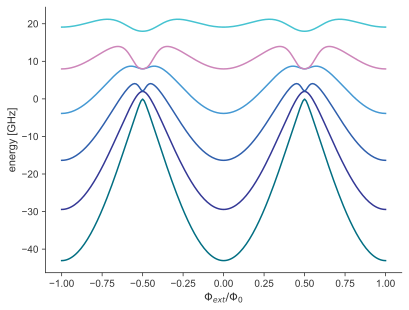

In [3]:
tune_tmon = scq.TunableTransmon(
   EJmax=50.0,
   EC=0.5,
   d=0.01,
   flux=0.0,
   ng=0.0,
   ncut=30
)

flux_vals = np.linspace(-1, 1, 201)
tune_tmon.plot_evals_vs_paramvals(param_name='flux', param_vals=flux_vals)

# Custom circuit flux tunable transmon

{Φ1: (Branch(JJ, 1, 0, index: 1), [Branch(JJ, 1, 0, index: 0), Branch(JJ, 1, 0, index: 1)])}
['cutoff_n_1']


Spectral data:   0%|          | 0/201 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Φ1', ylabel='energy [GHz]'>)

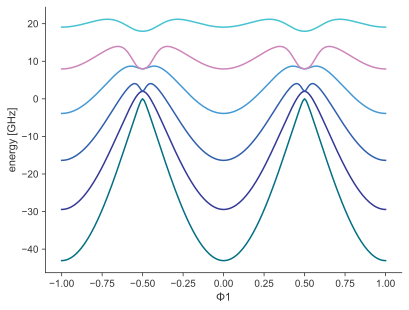

In [4]:
yaml_str = """
branches:
  # two Josephson junctions in parallel form a SQUID loop between node 1 and ground
  - [JJ, 1, 0, EJ1 = 25,  CJ1 = 1000]   # GHz units if no unit suffix provided. These are capacitive charging energies
  - [JJ, 1, 0, EJ2 = 25,  CJ2 = 1000]
  # shunt capacitor (sets EC)
  - [C,  1, 0, Csh = 0.5]  # GHz units, capactive charging energy           
"""

circ = scq.Circuit(yaml_str, from_file=False)

# Optional: show which loop got the flux and its symbol name:
print(circ.sym_external_fluxes())   # maps Φ1 to a loop definition

flux_vals = np.linspace(-1, 1, 201)
print(circ.cutoff_names)
circ.cutoff_n_1 = 30
circ.plot_evals_vs_paramvals("Φ1", param_vals=flux_vals, evals_count=6)